# Can latent geometry predict detection, without running the detector?

This notebook tests the sharpest prediction the theory makes, and it is sharp
because it is cross modal: it links a quantity measured with **no perturbation at
all** to the output of a perturbation based detector.

## The argument in 4 steps

**1. What the detector measures.** A second order expansion of PSU
(`docs/theory-perturbation-consistency.md`) gives

$$\phi(x) \;\approx\; -\tfrac{1}{2}\operatorname{tr}\!\big(H(x)\,\Sigma\big)$$

where $H$ is the Hessian of the predicted class probability at the probe site and
$\Sigma$ is the perturbation's covariance. The position sets $H$, the operator
sets $\Sigma$.

**2. Curvature is a margin statement.** For a softmax, every second derivative of
$P_c$ tends to 0 as the logit gap grows, because a saturated softmax is flat. So
low curvature means large margin, and low PSU means "far from any boundary".

**3. Where the margin comes from.** Write $r(x)$ for the effective dimension of
the locally class discriminative subspace. A direction along which no class
competes with $c$ is a direction along which $P_c$ is flat and contributes no
curvature, so

$$\operatorname{tr}(H) \;\approx\; r(x)\,\bar{\lambda}(x)
\qquad\Longrightarrow\qquad
\phi(x) \;\approx\; -\tfrac{\sigma^2}{2}\,r(x)\,\bar{\lambda}(x)$$

**4. The prediction.** If a backdoor works by routing triggered inputs onto a low
dimensional attractor, then the **rank ratio**, the effective rank of the
triggered population over that of the clean population, is a direct proxy for
what the detector reads. A lower rank ratio should mean a larger PSU gap, hence a
higher detection AUROC.

**A null result here is informative.** It would mean the collapse is a correlate
of the backdoor rather than the cause of the margin, and step 3 would have to go.

In [1]:
import os
import sys
from pathlib import Path

# Anchor at the repository root so every default path in psbd resolves the same
# way it does from a script, whichever directory the notebook was opened from.
REPO_ROOT = next(
    parent for parent in [Path.cwd(), *Path.cwd().parents]
    if (parent / "pyproject.toml").exists()
)
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

MEASURED = "experiments/latent_geometry_predicts_detection/geometry_vs_detection.csv"
frame = pd.read_csv(MEASURED)

failures = frame["error"].notna().sum()
frame = frame[frame["error"].isna()].copy()
frame["is_benign"] = frame["attack"] == "benign"
frame["is_evasive"] = frame["folder"].str.contains("evade")

print(f"{len(frame)} checkpoints measured, {failures} failed")
print(frame.groupby(["architecture", "dataset"]).size().to_string())

282 checkpoints measured, 0 failed
architecture  dataset 
swin          cifar10     25
              cifar100    57
              tiny        30
vit           cifar10     39
              cifar100    57
              gtsrb       22
              tiny        52


## What is being correlated

`best_deployable_auroc` is the best AUROC any **deployable** rule achieved on that
checkpoint in the cached sweep. Oracle rules are excluded, because a rule that
places its threshold using the labels it is trying to predict is not a detector.

`min_rank_ratio` is the deepest collapse over the block stack, measured on paired
clean and triggered features with no probe attached anywhere.

The 2 numbers come from completely separate pipelines. Nothing in the latent
measurement knows what the detector scored.

In [2]:
frame[[
    "best_deployable_auroc", "min_rank_ratio", "min_cka",
    "max_separation_auroc", "max_target_alignment", "rank_ratio_depth",
]].describe().round(4)

,best_deployable_auroc,min_rank_ratio,min_cka,max_separation_auroc,max_target_alignment,rank_ratio_depth
count,282.0000,282.0000,282.0000,282.0000,282.0000,282.0000
mean,0.8582,0.4646,0.4704,0.9891,0.5158,0.7971
std,0.1663,0.3153,0.2926,0.0456,0.2473,0.1897
min,0.5003,0.0140,0.0420,0.5810,-0.0141,0.1667
25%,0.7291,0.1431,0.1903,0.9996,0.3793,0.6667
50%,0.9513,0.4497,0.4393,1.0000,0.5689,0.8333
75%,0.9932,0.7272,0.7373,1.0000,0.6859,0.9583
max,1.0000,0.9957,0.9989,1.0000,0.9502,1.0000


## The prediction, tested

Spearman rather than Pearson: the theory predicts a monotone relationship, not a
linear one, and AUROC is bounded so a linear fit would be misspecified at the top.

In [3]:
def correlate(subset, label):
    rows = []
    for column in ("min_rank_ratio", "min_cka", "max_separation_auroc", "max_target_alignment"):
        usable = subset[[column, "best_deployable_auroc"]].dropna()
        if len(usable) < 10:
            continue
        rho, p_value = stats.spearmanr(usable[column], usable["best_deployable_auroc"])
        rows.append(
            {
                "population": label,
                "predictor": column,
                "n": len(usable),
                "spearman_rho": rho,
                "p_value": p_value,
            }
        )
    return rows


correlations = pd.DataFrame(
    correlate(frame, "all")
    + correlate(frame[~frame["is_benign"]], "backdoored only")
    + correlate(frame[frame["architecture"] == "vit"], "vit only")
    + correlate(frame[frame["architecture"] == "swin"], "swin only")
)
correlations.round(4)

,population,predictor,n,spearman_rho,p_value
0,all,min_rank_ratio,282,-0.5645,0.0
1,all,min_cka,282,-0.6948,0.0
2,all,max_separation_auroc,282,0.5264,0.0
3,all,max_target_alignment,282,0.5014,0.0
4,backdoored only,min_rank_ratio,277,-0.5409,0.0
5,backdoored only,min_cka,277,-0.6781,0.0
6,backdoored only,max_separation_auroc,277,0.4984,0.0
7,backdoored only,max_target_alignment,277,0.4915,0.0
8,vit only,min_rank_ratio,170,-0.6518,0.0
9,vit only,min_cka,170,-0.7407,0.0


The sign is what to read first. The theory predicts a **negative** rho for
`min_rank_ratio`: more collapse, so a smaller ratio, should mean easier detection
and a higher AUROC. A positive rho would refute step 3 directly.

`max_separation_auroc` is included as the comparison. Notebook 02 showed it rises
even on benign models, so if it predicts detection as well as the collapse
measures do, the collapse framing adds nothing.

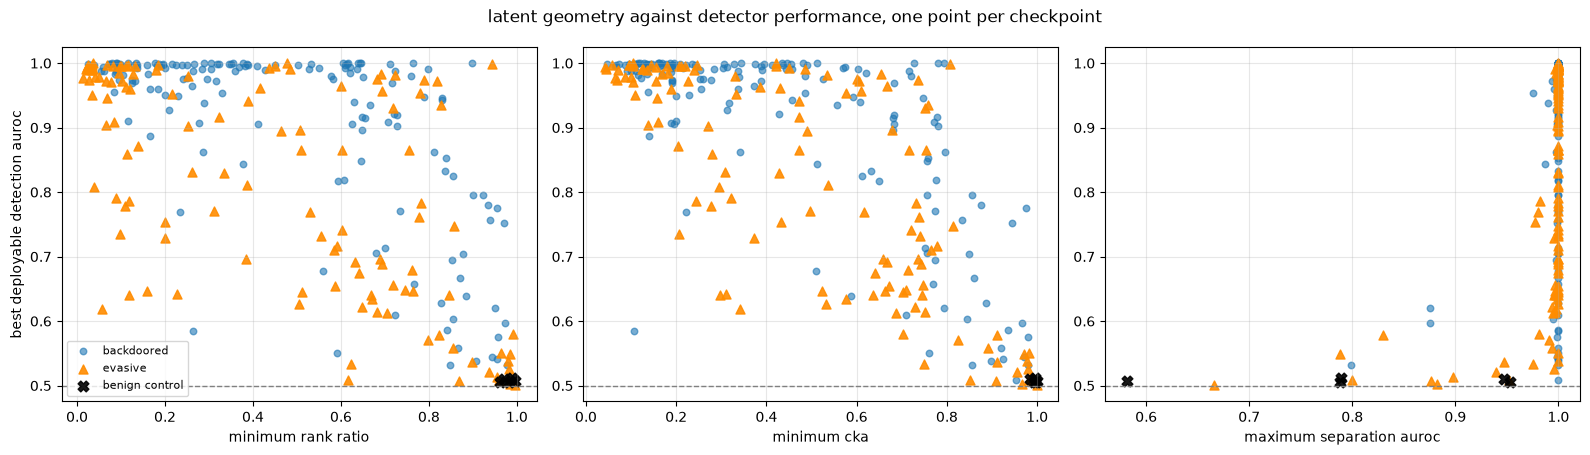

In [4]:
figure, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for axis, column, name in zip(
    axes,
    ("min_rank_ratio", "min_cka", "max_separation_auroc"),
    ("minimum rank ratio", "minimum cka", "maximum separation auroc"),
):
    for label, subset, style in (
        ("backdoored", frame[~frame["is_benign"] & ~frame["is_evasive"]], dict(alpha=0.6, s=22)),
        ("evasive", frame[frame["is_evasive"]], dict(alpha=0.9, s=42, marker="^", c="darkorange")),
        ("benign control", frame[frame["is_benign"]], dict(alpha=0.9, s=60, marker="X", c="black")),
    ):
        if len(subset):
            axis.scatter(subset[column], subset["best_deployable_auroc"], label=label, **style)
    axis.axhline(0.5, ls="--", lw=1, c="grey")
    axis.set_xlabel(name)
    axis.grid(alpha=0.3)
axes[0].set_ylabel("best deployable detection auroc")
axes[0].legend(fontsize=8)
figure.suptitle("latent geometry against detector performance, one point per checkpoint")
figure.tight_layout()
plt.show()

## Does it hold within a dataset and architecture?

A correlation across the whole sample can be produced entirely by between-group
differences: if ViT collapses more than Swin and is also easier to detect, the
pooled correlation says nothing about the mechanism. The test that matters is
whether it survives inside each group.

In [5]:
within_rows = []
for (architecture, dataset), group in frame[~frame["is_benign"]].groupby(["architecture", "dataset"]):
    usable = group[["min_rank_ratio", "best_deployable_auroc"]].dropna()
    if len(usable) < 8:
        continue
    rho, p_value = stats.spearmanr(usable["min_rank_ratio"], usable["best_deployable_auroc"])
    within_rows.append(
        {
            "architecture": architecture,
            "dataset": dataset,
            "n": len(usable),
            "spearman_rho": rho,
            "p_value": p_value,
        }
    )

within = pd.DataFrame(within_rows)
within.round(4)

,architecture,dataset,n,spearman_rho,p_value
0,swin,cifar10,25,-0.4531,0.0229
1,swin,cifar100,56,-0.3786,0.0040
2,swin,tiny,30,-0.6961,0.0000
3,vit,cifar10,38,-0.8481,0.0000
4,vit,cifar100,56,-0.6418,0.0000
5,vit,gtsrb,21,-0.3636,0.1051
6,vit,tiny,51,-0.6632,0.0000


In [6]:
if len(within):
    negative = (within["spearman_rho"] < 0).sum()
    print(f"groups with the predicted negative sign: {negative} of {len(within)}")
    print(f"median within-group rho: {within['spearman_rho'].median():.4f}")

groups with the predicted negative sign: 7 of 7
median within-group rho: -0.6418


## Per attack

Different attacks write their triggers differently, so the collapse should vary
with the attack. Whether the **relationship** varies is a different question, and
a relationship that only holds for one attack family is a much weaker result.

In [7]:
by_attack = (
    frame[~frame["is_benign"]]
    .groupby("attack")
    .agg(
        n=("folder", "size"),
        mean_auroc=("best_deployable_auroc", "mean"),
        mean_rank_ratio=("min_rank_ratio", "mean"),
        mean_cka=("min_cka", "mean"),
    )
    .sort_values("mean_rank_ratio")
)
by_attack.round(4)

,n,mean_auroc,mean_rank_ratio,mean_cka
attack,,,,
bpp,34,0.9878,0.1412,0.1353
blend,34,0.9933,0.1628,0.1681
lf,34,0.9428,0.2070,0.2178
wanet,27,0.8060,0.3652,0.4313
adaptive_blend,30,0.9272,0.5930,0.6176
badnet_a2o,34,0.9545,0.5995,0.4813
sig,17,0.6885,0.6055,0.6237
lc,27,0.7798,0.6553,0.7143
badnet_a2a,26,0.6855,0.7807,0.7901


## Where the collapse sits in the stack

`rank_ratio_depth` is the relative depth at which the collapse is deepest. The
placement result says the probe should be attached where the backdoor is, so if
the theory holds these should be related.

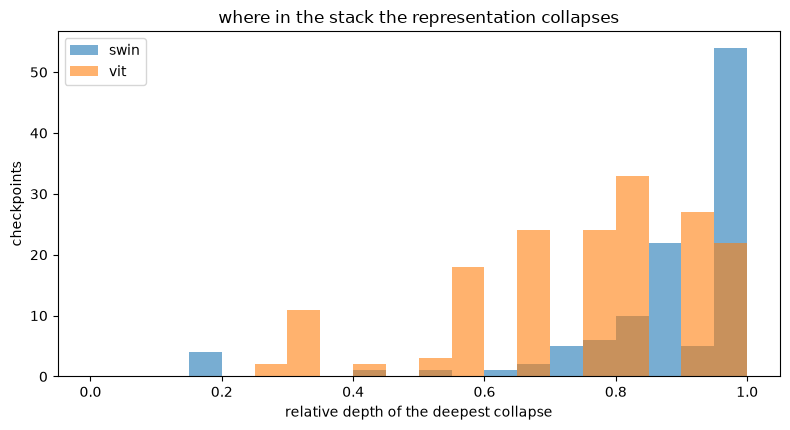

              count   mean    std    min    25%    50%    75%  max
architecture                                                      
swin          111.0  0.868  0.173  0.167  0.833  0.917  0.958  1.0
vit           166.0  0.755  0.188  0.250  0.667  0.750  0.917  1.0


In [8]:
figure, axis = plt.subplots(figsize=(8, 4.4))
for architecture, group in frame[~frame["is_benign"]].groupby("architecture"):
    axis.hist(group["rank_ratio_depth"].dropna(), bins=20, range=(0, 1), alpha=0.6, label=architecture)
axis.set_xlabel("relative depth of the deepest collapse")
axis.set_ylabel("checkpoints")
axis.set_title("where in the stack the representation collapses")
axis.legend()
figure.tight_layout()
plt.show()

print(frame[~frame["is_benign"]].groupby("architecture")["rank_ratio_depth"].describe().round(3).to_string())

## The benign and evasive checkpoints

The benign controls should sit at rank ratio near 1 and AUROC near 0.5, in the
corner of the plot. The evasive checkpoints are the interesting case: an attacker
who trained specifically against the detector should have moved the AUROC. Whether
they also moved the **geometry** says whether the collapse is something an
attacker can hide, which is the question that decides if this is a usable
detection signal or only an explanation.

In [9]:
special = frame[frame["is_benign"] | frame["is_evasive"]][
    ["folder", "architecture", "attack", "best_deployable_auroc", "min_rank_ratio", "min_cka"]
]
special.sort_values("best_deployable_auroc").round(4)

,folder,architecture,attack,best_deployable_auroc,min_rank_ratio,min_cka
236,vit_tiny_badnet_a2a_0_01_evade_l1,vit,badnet_a2a,0.5003,0.9948,0.9989
108,swin_tiny_tact_0_1_evade_l1,swin,tact,0.5017,0.9845,0.9658
247,vit_tiny_benign,vit,benign,0.5053,0.9821,0.9968
181,vit_cifar10_benign,vit,benign,0.5057,0.9627,0.9939
216,vit_gtsrb_benign,vit,benign,0.5069,0.9957,0.9988
...,...,...,...,...,...,...
96,swin_tiny_bpp_0_1_evade_l1,swin,bpp,0.9975,0.0337,0.0574
31,swin_cifar100_bpp_0_1_evade_l1,swin,bpp,0.9975,0.1839,0.1445
16,swin_cifar100_badnet_a2o_0_1_evade_l1,swin,badnet_a2o,0.9990,0.9442,0.8061
88,swin_tiny_badnet_a2o_0_01_evade_l1,swin,badnet_a2o,0.9997,0.4772,0.4217


## The control that decides whether this is a finding or a restatement

A backdoor that does not work cannot collapse anything, so rank ratio is bound to
correlate with attack success. If it correlates with **detection** only because
both track ASR, then the collapse measure has re-derived ASR the hard way and adds
nothing.

The test is a partial correlation: does rank ratio still predict detection AUROC
once ASR is held fixed? Attack success is recorded in the cached sweep, so it can
be joined back by checkpoint without re-measuring anything.

In [10]:
summary_frame = pd.read_csv("results/detection_summary.csv")
asr_by_folder = summary_frame.groupby("folder")["asr"].first()
frame["asr"] = frame["folder"].map(asr_by_folder)

joined = frame[~frame["is_benign"]].dropna(
    subset=["asr", "min_rank_ratio", "best_deployable_auroc"]
)
print(f"{len(joined)} backdoored checkpoints with both asr and geometry")


# Spearman correlation of x and y after regressing the control out of both.
# Done on ranks, so it is the nonparametric partial correlation rather than a
# linear one, matching the Spearman used everywhere else here.
def partial_spearman(frame_in, x, y, control):
    ranks = frame_in[[x, y, control]].rank()
    residuals = {}
    for column in (x, y):
        slope = np.polyfit(ranks[control], ranks[column], 1)
        residuals[column] = ranks[column] - np.polyval(slope, ranks[control])
    rho, p_value = stats.spearmanr(residuals[x], residuals[y])
    return rho, p_value


rows = []
for predictor in ("min_rank_ratio", "min_cka", "max_separation_auroc"):
    plain = stats.spearmanr(joined[predictor], joined["best_deployable_auroc"])
    with_asr = stats.spearmanr(joined[predictor], joined["asr"])
    partial = partial_spearman(joined, predictor, "best_deployable_auroc", "asr")
    rows.append(
        {
            "predictor": predictor,
            "rho_with_auroc": plain.statistic,
            "rho_with_asr": with_asr.statistic,
            "partial_rho_given_asr": partial[0],
            "partial_p": partial[1],
        }
    )
pd.DataFrame(rows).round(4)

277 backdoored checkpoints with both asr and geometry


,predictor,rho_with_auroc,rho_with_asr,partial_rho_given_asr,partial_p
0,min_rank_ratio,-0.5409,-0.4513,-0.3102,0.0000
1,min_cka,-0.6781,-0.6297,-0.3417,0.0000
2,max_separation_auroc,0.4984,0.5561,0.0949,0.1149


Read `partial_rho_given_asr` against `rho_with_auroc`. If the partial correlation
retains most of the raw one, the geometry carries information about detection that
attack success does not. If it collapses toward 0, the honest conclusion is that
rank ratio is a proxy for ASR and should be reported as such rather than as a
mechanism.

`rho_with_asr` is worth reading on its own. A very strong value there means the
measure is close to an ASR estimator, which would be a useful and cheap thing to
have but a different claim entirely.

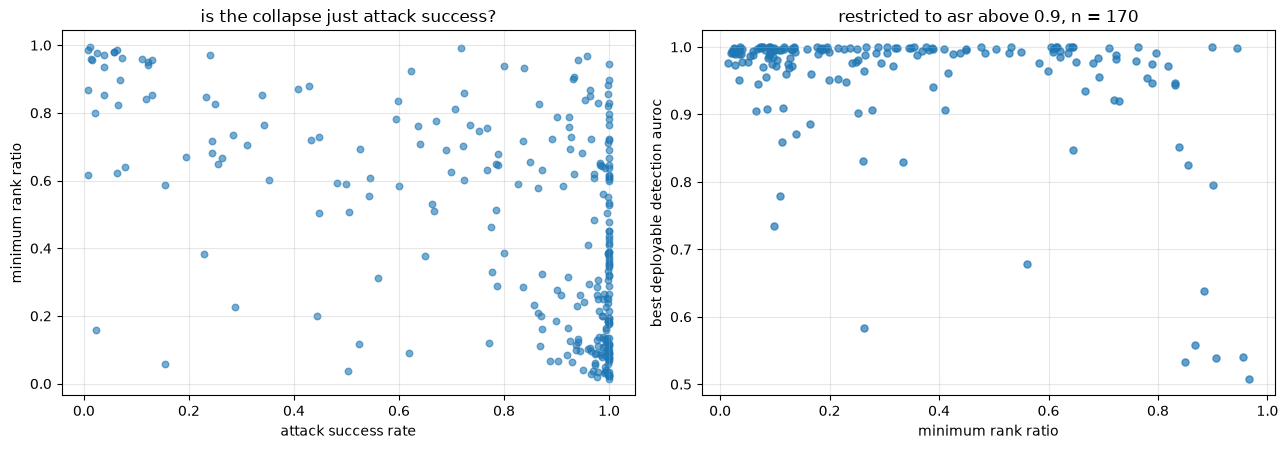

within the high-asr band: rho -0.1565, p 0.04153, n 170


In [11]:
figure, axes = plt.subplots(1, 2, figsize=(13, 4.6))
axes[0].scatter(joined["asr"], joined["min_rank_ratio"], alpha=0.6, s=22)
axes[0].set_xlabel("attack success rate")
axes[0].set_ylabel("minimum rank ratio")
axes[0].set_title("is the collapse just attack success?")

# Within a narrow ASR band the collapse should still vary if it is its own signal.
band = joined[joined["asr"] > 0.9]
axes[1].scatter(band["min_rank_ratio"], band["best_deployable_auroc"], alpha=0.7, s=26)
axes[1].set_xlabel("minimum rank ratio")
axes[1].set_ylabel("best deployable detection auroc")
axes[1].set_title(f"restricted to asr above 0.9, n = {len(band)}")
for axis in axes:
    axis.grid(alpha=0.3)
figure.tight_layout()
plt.show()

if len(band) > 10:
    rho, p_value = stats.spearmanr(band["min_rank_ratio"], band["best_deployable_auroc"])
    print(f"within the high-asr band: rho {rho:.4f}, p {p_value:.4g}, n {len(band)}")

## Verdict

Read the sign and the within-group table together. The claim only survives if the
correlation has the predicted sign, is not an artifact of pooling groups, and is
stronger for the collapse measures than for raw separability.

If it survives, the practical consequence is worth stating plainly: a defender
holding a model and a candidate trigger can estimate how well perturbation based
detection will work on it **before** running any sweep, from 2 forward passes over
a few hundred images. If it does not, step 3 of the argument is wrong and the
collapse is a symptom rather than the source of the margin.